# TCP-DI

In [1]:
import os
import pandas as pd

def load_data(scale):
    directory = f"./data/TPC-DI/Join/scale_{scale}"
    history_path = os.path.join(directory, "HoldingHistory.csv")
    trade_path = os.path.join(directory, "Trade.csv")
    history_df = pd.read_csv(history_path)
    trade_df = pd.read_csv(trade_path)
    return history_df, trade_df

# history_df, trade_df = load_data(scale=3)
# display(history_df.head())
# display(trade_df.head())

# joined_df = pd.merge(history_df, trade_df, left_on="HH_T_ID", right_on="T_ID", how="inner")
# display(joined_df.head())

In [2]:
scales = [3, 5, 9, 15, 20]

In [3]:
def init_provenance(method, scale):
    if method =="coo":
        from tensor_prov.provenance_coo import Provenance
    elif method == "csr":
        from tensor_prov.provenance_csr import Provenance
    elif method == "pandas":
        from tensor_prov.provenance_pandas import Provenance
    prov = Provenance(save_dir=f"results_TCPDI_{method}/scale_{scale}", verbose=1)
    return prov

In [4]:
def compute_capture_runtime(scales, method="coo"):
    for scale in scales:
        print(f"\n-- Scale: {scale} --\n")
        prov = init_provenance(method, scale)
        history_df, trade_df = load_data(scale=scale)
        history_wdf = prov.subscribe(history_df)
        trade_wdf = prov.subscribe(trade_df)    
        joined_wdf = history_wdf.merge(trade_wdf, left_on="HH_H_T_ID", right_on="T_ID", how="inner")
        print("joined_wdf.shape:", joined_wdf.shape)    
    return prov.runtimes

In [5]:
capture_runtimes_coo = compute_capture_runtime(scales, "coo")


-- Scale: 3 --


[capture] Runtime: 2.3845 s
joined_wdf.shape: (362342, 18)

-- Scale: 5 --


[capture] Runtime: 4.0639 s
joined_wdf.shape: (602956, 18)

-- Scale: 9 --


[capture] Runtime: 7.1411 s
joined_wdf.shape: (1085239, 18)

-- Scale: 15 --


[capture] Runtime: 11.9259 s
joined_wdf.shape: (1807703, 18)

-- Scale: 20 --


[capture] Runtime: 16.0324 s
joined_wdf.shape: (2411006, 18)


In [6]:
capture_runtimes_pandas = compute_capture_runtime(scales, "pandas")


-- Scale: 3 --


[capture] Runtime: 1.0904 s
joined_wdf.shape: (362342, 18)

-- Scale: 5 --


[capture] Runtime: 2.4616 s
joined_wdf.shape: (602956, 18)

-- Scale: 9 --


[capture] Runtime: 3.9250 s
joined_wdf.shape: (1085239, 18)

-- Scale: 15 --


[capture] Runtime: 7.3534 s
joined_wdf.shape: (1807703, 18)

-- Scale: 20 --


[capture] Runtime: 10.4398 s
joined_wdf.shape: (2411006, 18)


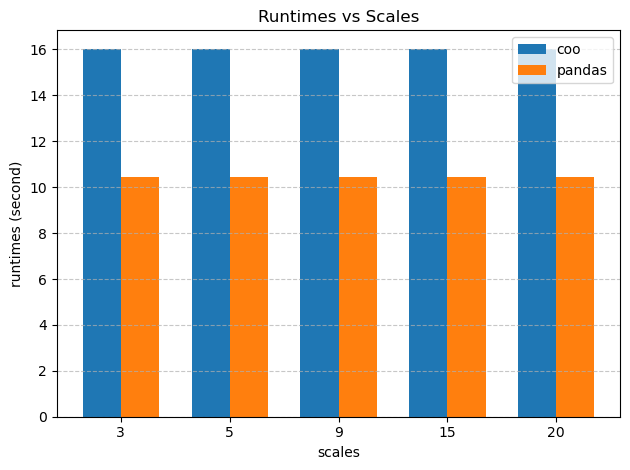

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(scales))
width = 0.35

plt.figure()
plt.bar(x - width/2, capture_runtimes_coo, width=width, label='coo', color='tab:blue')
plt.bar(x + width/2, capture_runtimes_pandas, width=width, label='pandas', color='tab:orange')

plt.xticks(x, [str(s) for s in scales])
plt.xlabel('scales')
plt.ylabel('runtimes (second)')
plt.title('Runtimes vs Scales')
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
from pathlib import Path

def get_dir_size(path: Path) -> int:
    return sum(f.stat().st_size for f in path.rglob("*") if f.is_file())

def compute_provenance_size(scales, method="coo"):
    base = Path(f"results_TCPDI_{method}")
    sizes = []
    
    for scale in scales:
        folder = base / f"scale_{scale}"
        print(f"\n-- Scale: {scale} --\n")
        if folder.exists() and folder.is_dir():
            size_bytes = get_dir_size(folder)
            size_mb = size_bytes / (1024**2)
            sizes.append(size_mb)
            print(f"{folder.name}: {size_mb:.2f} MB")
        else:
            print(f"{folder.name} not exists")
    return sizes

In [9]:
sizes_coo = compute_provenance_size(scales, "coo")


-- Scale: 3 --

scale_3: 2.17 MB

-- Scale: 5 --

scale_5: 3.61 MB

-- Scale: 9 --

scale_9: 6.50 MB

-- Scale: 15 --

scale_15: 10.90 MB

-- Scale: 20 --

scale_20: 14.58 MB


In [10]:
sizes_pandas = compute_provenance_size(scales, "pandas")


-- Scale: 3 --

scale_3: 11.06 MB

-- Scale: 5 --

scale_5: 18.40 MB

-- Scale: 9 --

scale_9: 33.12 MB

-- Scale: 15 --

scale_15: 55.17 MB

-- Scale: 20 --

scale_20: 73.58 MB


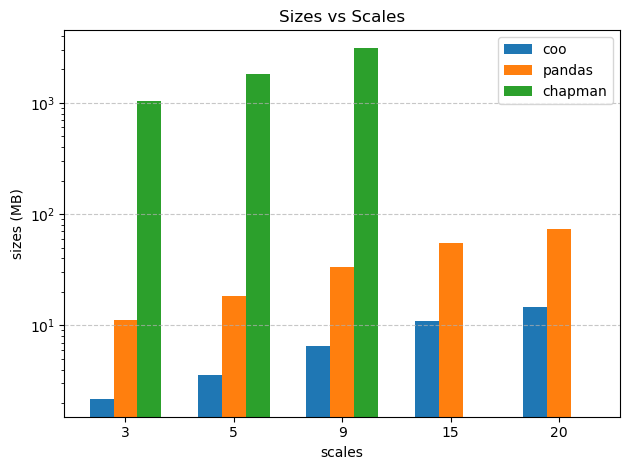

In [11]:
import numpy as np
import matplotlib.pyplot as plt

sizes_chapman = [1.02, 1.78, 3.04, 0, 0]
sizes_chapman = [x * 1024 for x in sizes_chapman]

x = np.arange(len(scales))
width = 0.22

plt.figure()
plt.bar(x - width,          sizes_coo,     width=width, label='coo',     color='tab:blue')
plt.bar(x,                  sizes_pandas,  width=width, label='pandas',  color='tab:orange')
plt.bar(x + width,          sizes_chapman, width=width, label='chapman', color='tab:green')

plt.xticks(x, [str(s) for s in scales])
plt.xlabel('scales')
plt.ylabel('sizes (MB)')
plt.title('Sizes vs Scales')
plt.yscale("log")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()